# CML to FAIRFluids Conversion - Composition-Based Approach

This notebook demonstrates how to convert CML (Chemical Markup Language) files to FAIRFluids format using the `FAIRFluidsCMLParser` class with the new **composition-based approach**.

## Key Features

- **Composition-based fluid creation**: $E_a$ch unique composition gets its own fluid block
- **Automatic compound ID generation** with consistent naming
- **Support for multiple property types** (viscosity, conductivity, density)
- **Intelligent composition grouping** based on mole fraction combinations
- **No filtering needed**: Only compounds present in each composition are included

## Overview

The parser automatically:
1. Extracts compounds from CML data or uses provided compound definitions
2. Generates consistent compound IDs using cleaned common names
3. **Groups measurements by unique compositions** (mole fraction combinations)
4. **Creates separate fluid blocks for each unique composition**
5. **Only includes compounds with non-zero mole fractions in each fluid**
6. Creates parameter definitions specific to each composition
7. Assigns measurements to the appropriate fluid based on composition

## Important Notes

- **Composition-Based Approach**: $E_a$ch unique composition becomes a separate fluid block
- **No Zero Mole Fractions**: Compounds with zero mole fractions are automatically excluded from each fluid
- **Consistent IDs**: Compound and parameter IDs use cleaned names for consistency
- **Clean Data Structure**: No post-processing filtering needed - data is structured correctly from the start

In [1]:
# Import the FAIRFluids models
import sys
sys.path.append('/home/sga/Code/FAIRFluids')
from fairfluids import FAIRFluidsCMLParser
from fairfluids.core.lib import FAIRFluidsDocument, Version, Citation
from fairfluids.core.functionalities import FAIRFluidsCMLParser
from fairfluids import FAIRFluidsDocument, FluidIO
from fairfluids.operations import calculate_ratio_of_solvent
from fairfluids.core.visualization import extract_fairfluids_data, plot_dataframe
import pandas as pd


doc = FAIRFluidsDocument(
    version=Version(
        versionMajor=1,
        versionMinor=0
    )
)

# Define the compounds as variables (dictionaries) for use in a compounds list
# Note: compoundID will be automatically generated using the new consistent naming convention
compound_water = {
    "pubChemID": 962,
    "commonName": "Water",
    "name_IUPAC": "oxidane",
    "standard_InChI": "InChI=1S/H2O/h1H2",
    "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N"
}

compound_cholinechloride = {
    "pubChemID": 6209,
    "commonName": "Choline chloride",  # Updated to use proper spacing
    "name_IUPAC": "Choline chloride",
    "standard_InChI": "InChI=1S/C5H11ClNO2/c1"
}

compound_glycerol = {
    "pubChemID": 753,
    "commonName": "Glycerol",
    "name_IUPAC": "glycerol",
    "standard_InChI": "InChI=1S/C3H8O3/c1-2-3-4/h2-3H,1H3",
    "standard_InChI_key": "XLYOFNOQVPJJNP-UHFFFAOYSA-N"
}

compounds = [
        compound_cholinechloride,
        compound_glycerol,
        compound_water
    ]
    


# Path to the test CML file
cml_path = "/home/sga/Code/FAIRFluids/fairfluids/data/cml_xml/gygli/ChCl_glycerol.xml"
#cml_path = "/home/sga/Code/FAIRFluids/fairfluids/data/cml_xml/xu/CML_exp_sim.xml"


# Parse the CML file
parser = FAIRFluidsCMLParser(cml_path, compounds=compounds)
doc = parser.parse()

doc   = calculate_ratio_of_solvent(
    doc=doc,
    parameter_id_1="parameter_mole_fraction_glycerol",
    parameter_id_2="parameter_mole_fraction_cholinechloride",
    name="glycerol_cholinechloride",
    compound_id_1="compound_glycerol",
    compound_id_2="compound_cholinechloride",
    precision=1  # Round to 2 decimal places - ensures 2.0 instead of 2.0075...
)

# Add same data as example
doc.citation = Citation(Type="journal",)
doc.citation.add_to_author(given_name="Gudrun", family_name="Gygli")

# Save the model to a JSON file
with open('/home/sga/Code/FAIRFluids/Workflows/paper_outputs/Xu_Glycerol_Water.json', 'w') as f:
    f.write(doc.model_dump_json(indent=4))
    
print(f"\n📁 Output saved to: /home/sga/Code/FAIRFluids/Workflows/outputs/Xu_Glycerol_Water.json")

Fetching compound data from PubChem for CID 6209...
Successfully fetched and merged data for CID 6209
Fetching compound data from PubChem for CID 753...
Successfully fetched and merged data for CID 753
Fetching compound data from PubChem for CID 962...
Successfully fetched and merged data for CID 962
Found 30 unique compositions
Composition (0.25, 0.5, 0.25): compounds ['compound_cholinechloride', 'compound_glycerol', 'compound_water']
Composition (0.0, 0.0, 1.0): compounds ['compound_water']
Composition (0.006, 0.012, 0.982): compounds ['compound_cholinechloride', 'compound_glycerol', 'compound_water']
Composition (0.013, 0.027, 0.96): compounds ['compound_cholinechloride', 'compound_glycerol', 'compound_water']
Composition (0.022, 0.044, 0.933): compounds ['compound_cholinechloride', 'compound_glycerol', 'compound_water']
Composition (0.033, 0.066, 0.901): compounds ['compound_cholinechloride', 'compound_glycerol', 'compound_water']
Composition (0.048, 0.095, 0.857): compounds ['comp

In [2]:
doc.version = Version(
    versionMajor=1,
    versionMinor=0
)
doc

FAIRFluidsDocument(version=Version(versionMajor=1, versionMinor=0), citation=Citation(litType=None, author=[Author(given_name='Gudrun', family_name='Gygli', email=None, orcid=None, affiliation=None)], doi=None, page=None, pub_name=None, title=None, lit_volume_num=None, url_citation=None, publication_year=None), compound=[Compound(compoundID='compound_cholinechloride', pubChemID=6209, commonName='Choline Chloride', SELFIE=None, name_IUPAC='2-hydroxyethyl(trimethyl)azanium chloride', standard_InChI='InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1', standard_InChI_key='SGMZJAMFUVOLNK-UHFFFAOYSA-M', molar_weigth=139.62, smiles_code='C[N+](C)(C)CCO.[Cl-]', sigma_profile=None), Compound(compoundID='compound_glycerol', pubChemID=753, commonName='Glycerol', SELFIE=None, name_IUPAC='propane-1,2,3-triol', standard_InChI='InChI=1S/C3H8O3/c4-1-3(6)2-5/h3-6H,1-2H2', standard_InChI_key='PEDCQBHIVMGVHV-UHFFFAOYSA-N', molar_weigth=92.09, smiles_code='C(C(CO)O)O', sigma_profile=None), 

In [3]:
# Import der wiederverwendbaren Plot-Speicherfunktion
from fairfluids.core.plot_utils import save_plot_as_svg
# Global DOI style dictionary used for coloring
DOI_STYLES = {
    "10.1016/j.fluid.2014.01.028": {"color": "#1f77b4", "marker": "o"},
    "10.1016/j.fluid.2024.114324": {"color": "#ff7f0e", "marker": "s"},
    "10.1016/j.jct.2018.07.031": {"color": "#2ca02c", "marker": "^"},
    "10.1016/j.molliq.2015.11.032": {"color": "#d62728", "marker": "D"},
    "10.1016/j.molliq.2021.117463": {"color": "#9467bd", "marker": "v"},
    "10.1039/c0gc00395f": {"color": "#8c564b", "marker": "P"},
    "10.1039/c1cp22554e": {"color": "#e377c2", "marker": "X"},
}

DEFAULT_COLORS = ["#7f7f7f", "#17becf", "#bcbd22", "#aec7e8", "#ffbb78"]
DEFAULT_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "<", ">"]

def get_doi_style(doi):
    if doi in DOI_STYLES:
        return DOI_STYLES[doi]
    idx = abs(hash(doi)) % len(DEFAULT_COLORS)
    midx = abs(hash(doi)) % len(DEFAULT_MARKERS)
    return {"color": DEFAULT_COLORS[idx], "marker": DEFAULT_MARKERS[midx]}


In [4]:
from fairfluids.core.functionalities import extract_property_dataframe

# Extract dataframes for both doc and doc_csv
df1 = extract_property_dataframe(
    doc,
    property_type="viscosity",
    target_ratio=2.0,
    include_na_ratio=True,
)
df1["mole_fraction_water"] = df1["mole_fraction_water"].fillna(0)


# Combine both dataframes
import pandas as pd
#df1 = pd.concat([df1, df2], ignore_index=True)
#df1

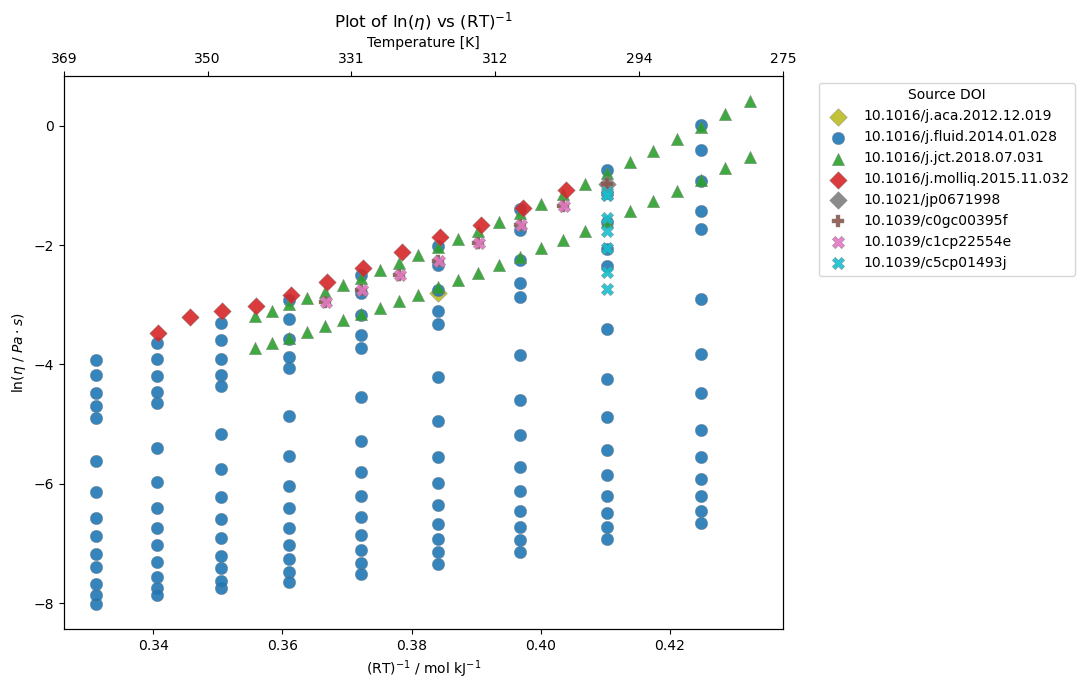

In [5]:
from fairfluids.core.visualization import plot_viscosity

# Use the imported DOI_STYLES and get_doi_style from (1-23)
doi_keys = sorted(df1["source_doi"].fillna("NA").astype(str).unique())
doi_styles = {doi: get_doi_style(doi) for doi in doi_keys if doi != "NA"}

fig, ax, plot_df = plot_viscosity(
    df1,
    color_by="source_doi",
    marker_by_group="source_doi",
    marker_styles=[doi_styles.get(doi, {"marker": "o"})["marker"] for doi in doi_keys],
    colors={doi: doi_styles[doi]["color"] for doi in doi_styles},
    show_errorbars=True,
)


/tmp/ipykernel_42689/3185590269.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


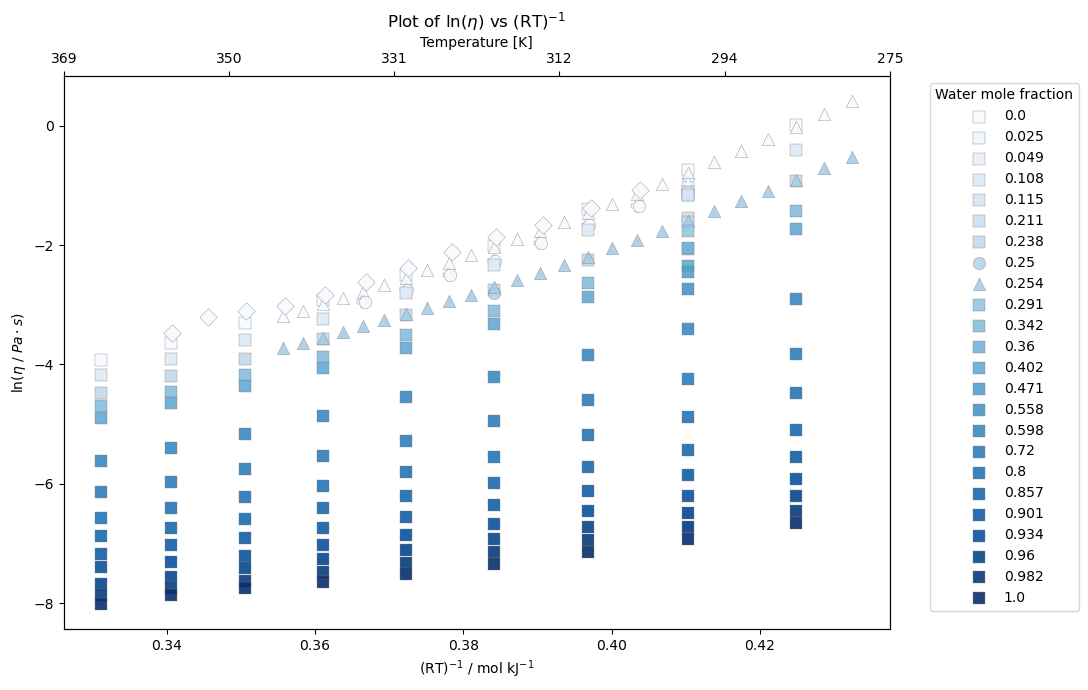

In [6]:
fig, ax, plot_df = plot_viscosity(
    df1,
    color_by="mole_fraction_water",
    cmap="Blues",
    marker_by_group="source_doi",
    marker_styles=["o", "s", "^", "D", "v", "P"],
)
fig.show()

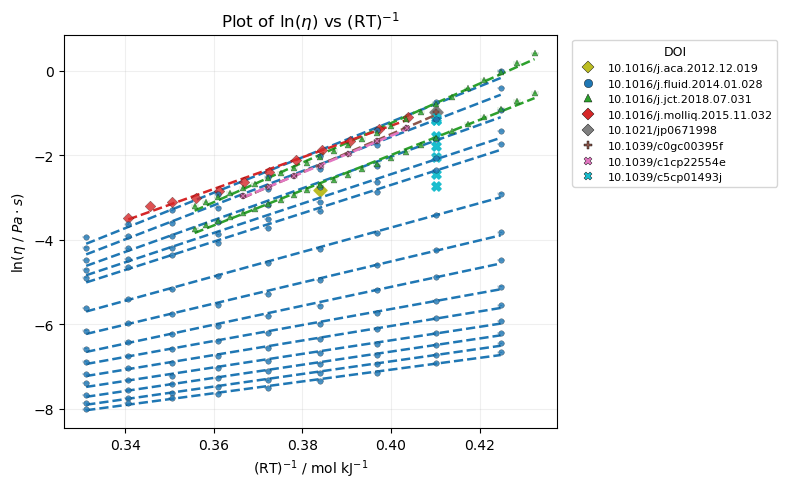

,source_doi,mole_fractions,lnAs,Ea_kJ_mol,R_squared,n_points,mole_fraction_water,Ea_kJ_mol_std
0,10.1016/j.fluid.2014.01.028,"(0.006033, 0.012067, 0.9819)",-12.841238,14.913351,0.995354,9,0.981900,0.385092
1,10.1016/j.fluid.2014.01.028,"(0.013267, 0.026533, 0.9602)",-12.863887,15.547530,0.996224,9,0.960200,0.361808
2,10.1016/j.fluid.2014.01.028,"(0.022167, 0.044333, 0.9335)",-12.784446,16.014764,0.991342,9,0.933500,0.565684
3,10.1016/j.fluid.2014.01.028,"(0.0331, 0.0662, 0.9007)",-12.922000,17.208717,0.994749,9,0.900700,0.472574
4,10.1016/j.fluid.2014.01.028,"(0.047533, 0.095067, 0.8574)",-13.195562,18.894579,0.995529,9,0.857400,0.478594
5,10.1016/j.fluid.2014.01.028,"(0.066767, 0.133533, 0.7997)",-14.060410,22.367791,0.993082,9,0.799700,0.705619
6,10.1016/j.fluid.2014.01.028,"(0.093367, 0.186733, 0.7199)",-14.486951,24.939969,0.995505,9,0.719900,0.633397
7,10.1016/j.fluid.2014.01.028,"(0.134067, 0.268133, 0.5978)",-15.259642,28.875893,0.996852,9,0.597800,0.613288
8,10.1016/j.fluid.2014.01.028,"(0.199267, 0.398533, 0.4022)",-16.112062,33.528280,0.993368,9,0.402200,1.035429
9,10.1016/j.fluid.2014.01.028,"(0.219167, 0.438333, 0.3425)",-16.344019,34.742627,0.992421,9,0.342500,1.147534


In [7]:
from fairfluids.core.functionalities import fit_arrhenius

arr_df2 = fit_arrhenius(
    df1,
    viscosity_col="viscosity_value",
    temperature_col="temperature",
    doi_col="source_doi",
    viscosity_uncertainty_col="viscosity_uncertainty",
    molefractions_col="mole_fractions",
    log_base="ln",
    include_water_mole_fraction=True,
    water_col="mole_fraction_water",
    show_plot=True,
    doi_plot_styles=doi_styles,

)

display(arr_df2[["source_doi", "mole_fractions", "lnAs", "Ea_kJ_mol", "R_squared", "n_points", "mole_fraction_water", "Ea_kJ_mol_std"]])

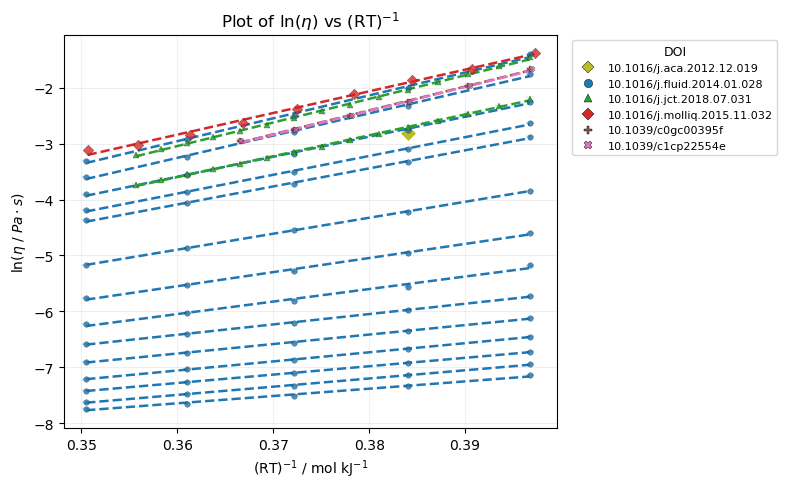

In [8]:
from fairfluids.core.functionalities import fit_arrhenius

arr_df = fit_arrhenius(
    df1,
    viscosity_col="viscosity_value",
    temperature_col="temperature",
    doi_col="source_doi",
    viscosity_uncertainty_col="viscosity_uncertainty",
    molefractions_col="mole_fractions",
    log_base="ln",
    include_water_mole_fraction=True,
    water_col="mole_fraction_water",
    t_range=(302,345),
    show_plot=True,
    doi_plot_styles=doi_styles,

)


/tmp/ipykernel_42689/2112152907.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(
/tmp/ipykernel_42689/2112152907.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^" (-> marker='^'). The keyword argument will take precedence.
  ax.errorbar(
/tmp/ipykernel_42689/2112152907.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "D" (-> marker='D'). The keyword argument will take precedence.
  ax.errorbar(
/tmp/ipykernel_42689/2112152907.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "P" (-> marker='P'). The keyword argument will take precedence.
  ax.errorbar(
/tmp/ipykernel_42689/2112152907.py:20: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "X" (-> marker

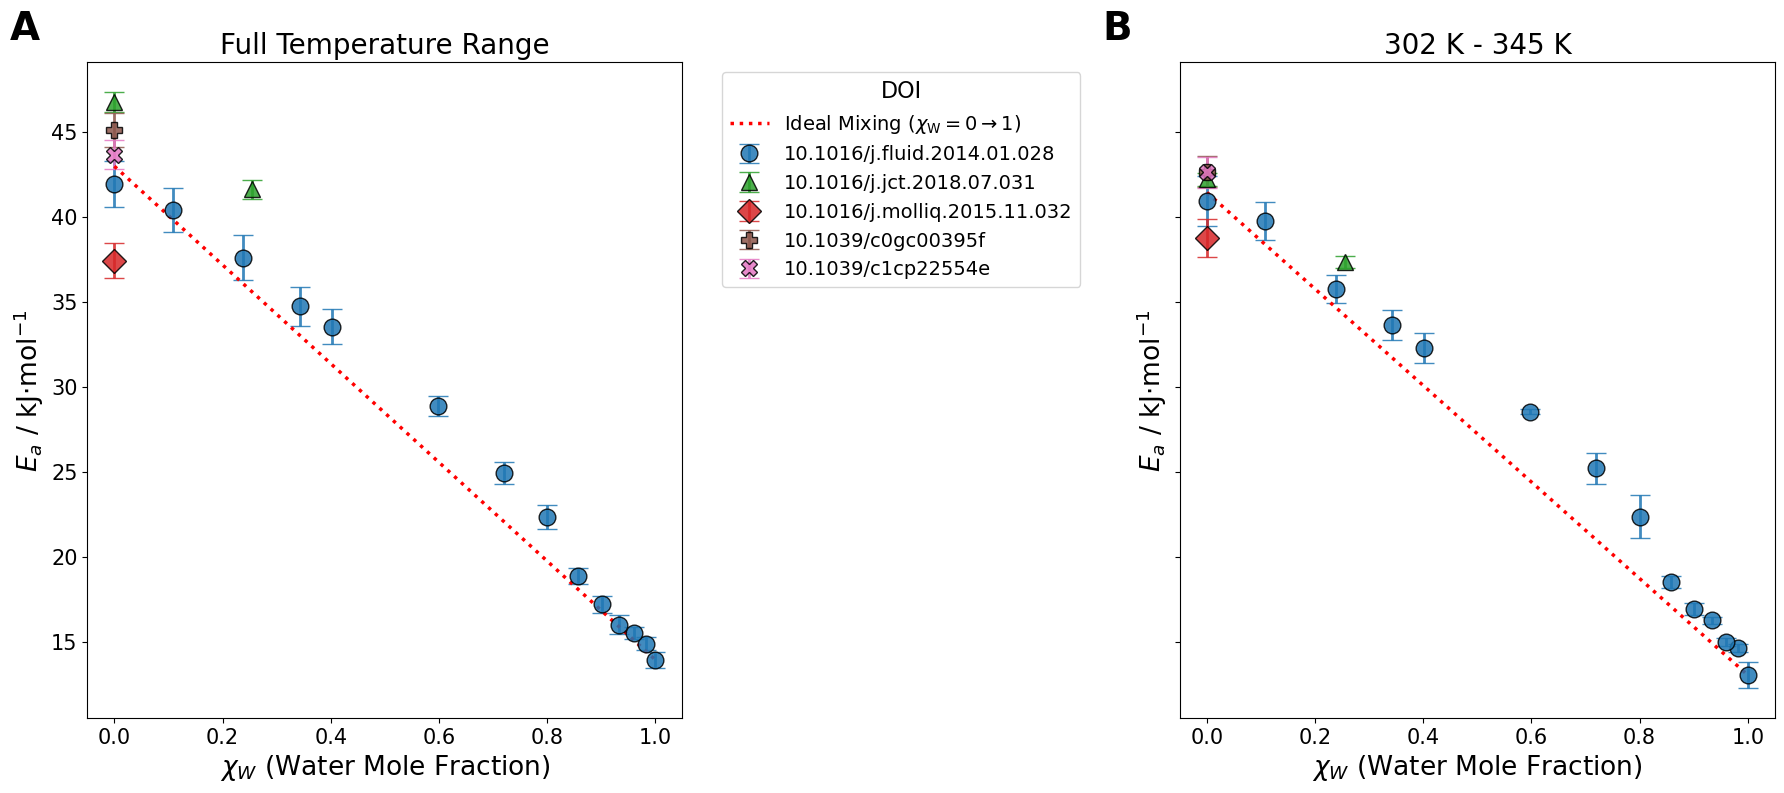

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Plot activation energies for arr_df and arr_df2 with error bars (Ea_kJ_mol_std)
fig, axs = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Switch datasets so "Full Range" is on the left (A), and (302 K - 345 K) is on the right (B)
datasets = [
    ("Full Temperature Range", arr_df2),
    ("302 K - 345 K", arr_df)
]
panel_labels = ["A", "B"]

for idx, (title, arr) in enumerate(datasets):
    ax = axs[idx]
    for doi in arr["source_doi"].unique():
        style = get_doi_style(doi)  # Uses function from the file context at the top of notebook
        subset = arr[arr["source_doi"] == doi]
        yerr = subset["Ea_kJ_mol_std"].values if "Ea_kJ_mol_std" in subset.columns else None
        ax.errorbar(
            subset["mole_fraction_water"],
            subset["Ea_kJ_mol"],
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            marker=style["marker"],
            markersize=12,
            linestyle='None',
            label=doi,
            alpha=0.85,
            markeredgecolor="black",
            ecolor=style["color"],
            elinewidth=2,
            capsize=7,
        )

    # Add the red dotted line between mean of mole fraction water 0 and 1
    zero_water = arr[arr["mole_fraction_water"] == 0.0]
    one_water = arr[arr["mole_fraction_water"] == 1.0]
    if not zero_water.empty and not one_water.empty:
        mean_0 = zero_water["Ea_kJ_mol"].mean()
        mean_1 = one_water["Ea_kJ_mol"].mean()
        ax.plot(
            [0.0, 1.0],
            [mean_0, mean_1],
            color="red",
            linestyle=":",
            linewidth=2.5,
            marker=None,
            zorder=2,
            label=r"Ideal Mixing ($\chi_{\mathrm{W}}=0 \rightarrow 1$)"
       
        )
    # Add panel label ("A" or "B") to the upper left of each subplot
    ax.text(-0.13, 1.08, panel_labels[idx], transform=ax.transAxes, fontsize=28, fontweight='bold', va='top', ha='left')

    ax.set_xlabel(r"$\chi_W$ (Water Mole Fraction)", fontsize=19)
    ax.set_title(title, fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=15)
    if idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        # remove duplicate labels
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(), by_label.keys(),
            title="DOI", title_fontsize=16, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=14
        )

# Set y-axis label for both subplots
for ax in axs:
    ax.set_ylabel(r"$E_a$ / kJ$\cdot$mol$^{-1}$", fontsize=19)
plt.tight_layout()
plt.show()

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_42689/2871764445.py:81: SyntaxWarning: invalid escape sequence '\c'
  legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of Activation Energy at $\chi_W = 0$'))


✓ Plot gespeichert: image_output/Arrhenius_fit_302_K_-_345_K_1.svg (69,754 Bytes)


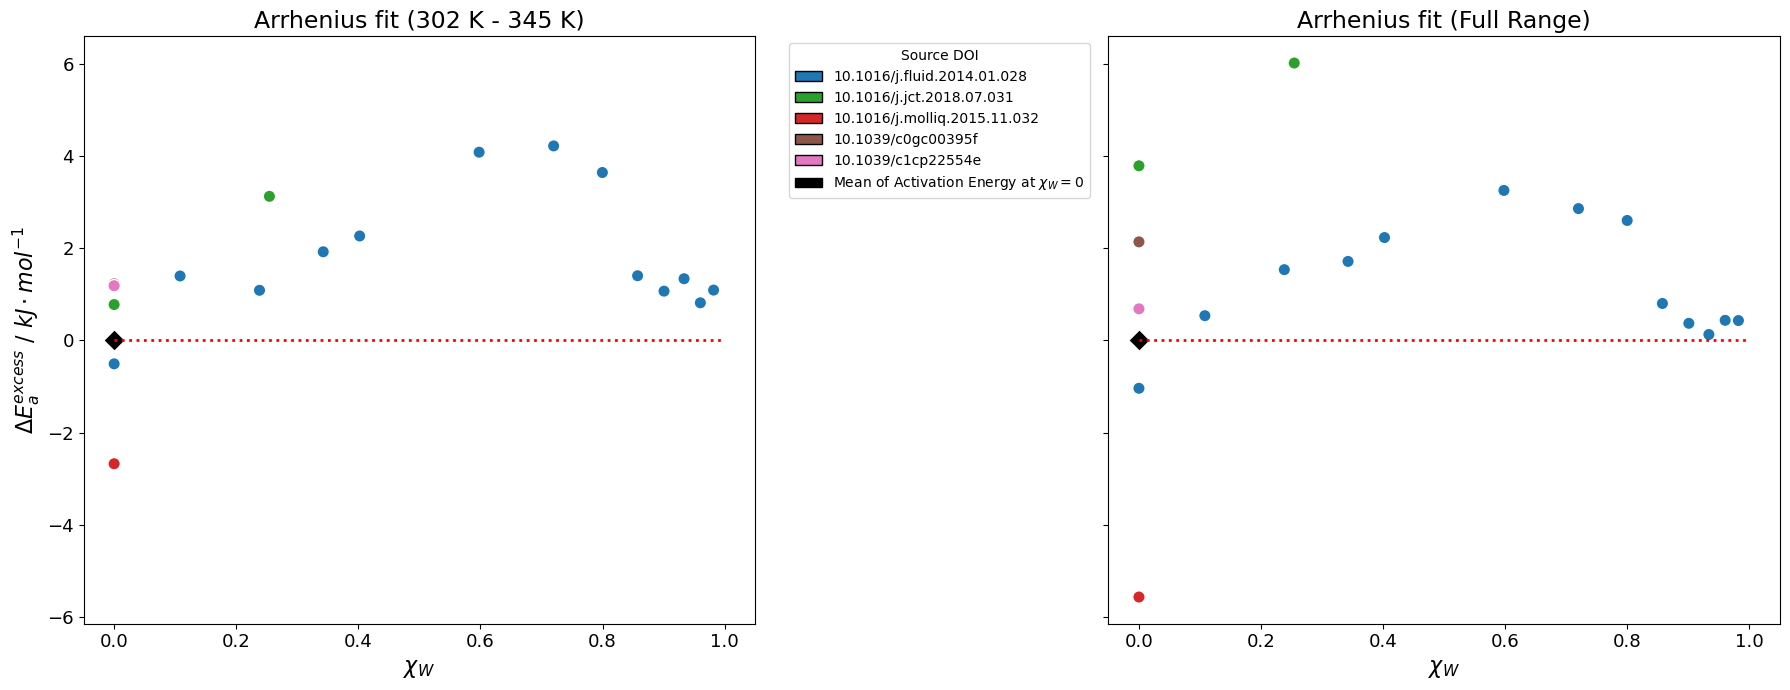

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

fig, axs = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

datasets = [
    ("Arrhenius fit (302 K - 345 K)", arr_df),
    ("Arrhenius fit (Full Range)", arr_df2)
]

# Use global DOI_STYLES, DEFAULT_COLORS, and DEFAULT_MARKERS defined earlier.
def get_style_for_doi(doi):
    if doi in DOI_STYLES:
        return DOI_STYLES[doi]
    idx = abs(hash(doi)) % len(DEFAULT_COLORS)
    midx = abs(hash(doi)) % len(DEFAULT_MARKERS)
    return {"color": DEFAULT_COLORS[idx], "marker": DEFAULT_MARKERS[midx]}

for i, (title, activation_energy_df) in enumerate(datasets):
    ax = axs[i]
    # Split data for water fraction
    zero_water_data = activation_energy_df[activation_energy_df['mole_fraction_water'] == 0.0]
    one_water_data = activation_energy_df[activation_energy_df['mole_fraction_water'] == 1.0]
    other_data = activation_energy_df[(activation_energy_df['mole_fraction_water'] != 0.0) & (activation_energy_df['mole_fraction_water'] != 1.0)]
    
    # Means at χ_w = 0 and 1
    mean_0_water = zero_water_data['Ea_kJ_mol'].mean()
    mean_1_water = one_water_data['Ea_kJ_mol'].mean()
    # Linear background
    water_fractions = activation_energy_df['mole_fraction_water']
    trend_line = mean_0_water + (mean_1_water - mean_0_water) * water_fractions
    delta_Ea_excess = activation_energy_df['Ea_kJ_mol'] - trend_line

    # χ_w = 0 points, colored per DOI
    if not zero_water_data.empty:
        ax.scatter(
            zero_water_data['mole_fraction_water'],
            delta_Ea_excess[zero_water_data.index],
            c=[get_style_for_doi(doi)["color"] for doi in zero_water_data['source_doi']],
            s=80,
            edgecolor='w'
        )
        # Black diamond = mean at χ_w = 0 (always zero, but emphasized)
        ax.scatter(
            [0.0],
            [0.0],
            c='black',
            s=120,
            edgecolor='w',
            marker='D',
            label='Mean (0% water)'
        )

    # Other χ_w points, colored per DOI
    if not other_data.empty:
        ax.scatter(
            other_data['mole_fraction_water'],
            delta_Ea_excess[other_data.index],
            c=[get_style_for_doi(doi)["color"] for doi in other_data['source_doi']],
            s=80,
            edgecolor='w'
        )

    # Mean trend: dashed red line 0 → 1
    ax.plot(
        [0.0, 1.0],
        [0.0, mean_1_water - (mean_0_water + (mean_1_water - mean_0_water) * 1.0)],
        'r:',
        linewidth=2,
        label='Mean trend'
    )

    # Per-DOI legend patches
    unique_dois = activation_energy_df['source_doi'].unique()
    legend_handles = []
    for doi in unique_dois:
        color = get_style_for_doi(doi)['color']
        legend_handles.append(Patch(facecolor=color, edgecolor='k', label=f"{doi}"))
    # Black: mean χ_w = 0
    legend_handles.append(Patch(facecolor='black', edgecolor='k', label='Mean of Activation Energy at $\chi_W = 0$'))
    if i == 0:
        ax.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)

    ax.set_xlabel(r"$\chi_W$", fontsize=16)
    ax.set_title(title, fontsize=17)
    ax.tick_params(axis='both', which='major', labelsize=13)

axs[0].set_ylabel(r"$\Delta E_a^{excess}$ / $kJ \cdot mol^{-1}$", fontsize=16)
plt.tight_layout()
save_plot_as_svg()
plt.show()

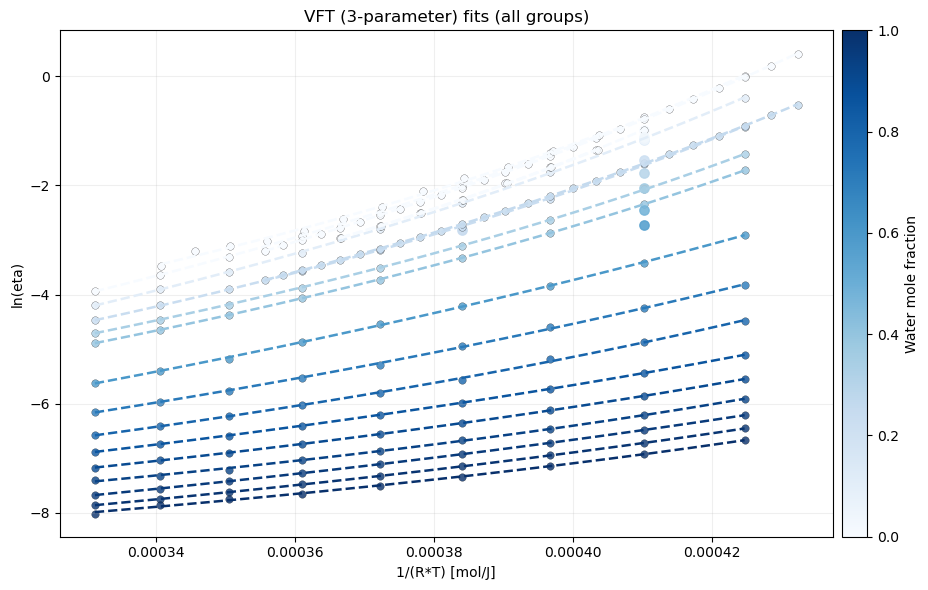

,source_doi,mole_fractions,n_points,eta0,ln_eta0,B,T0,eta0_std,ln_eta0_std,B_std,T0_std,R_squared,T_min,T_max,mole_fraction_water
0,10.1016/j.fluid.2014.01.028,"(0.006033, 0.012067, 0.9819)",9,0.000041,-10.096503,464.349754,155.686019,0.000003,0.065177,21.071123,3.594613,0.999942,283.150,363.150,0.981900
1,10.1016/j.fluid.2014.01.028,"(0.013267, 0.026533, 0.9602)",9,0.000039,-10.150551,533.763252,147.691393,0.000003,0.083534,28.386688,4.436538,0.999928,283.150,363.150,0.960200
2,10.1016/j.fluid.2014.01.028,"(0.022167, 0.044333, 0.9335)",9,0.000075,-9.493373,392.478067,173.645983,0.000018,0.244885,70.019712,12.431684,0.998876,283.150,363.150,0.933500
3,10.1016/j.fluid.2014.01.028,"(0.0331, 0.0662, 0.9007)",9,0.000064,-9.659192,504.986109,160.342637,0.000004,0.069242,21.716612,3.300835,0.999945,283.150,363.150,0.900700
4,10.1016/j.fluid.2014.01.028,"(0.047533, 0.095067, 0.8574)",9,0.000059,-9.744454,596.960605,154.517724,0.000002,0.028808,9.382999,1.254785,0.999993,283.150,363.150,0.857400
5,10.1016/j.fluid.2014.01.028,"(0.066767, 0.133533, 0.7997)",9,0.000062,-9.686642,614.835619,165.318390,0.000021,0.342668,103.929152,12.528728,0.999097,283.150,363.150,0.799700
6,10.1016/j.fluid.2014.01.028,"(0.093367, 0.186733, 0.7199)",9,0.000042,-10.087357,840.048734,149.290236,0.000014,0.337600,113.608546,11.168414,0.999525,283.150,363.150,0.719900
7,10.1016/j.fluid.2014.01.028,"(0.134067, 0.268133, 0.5978)",9,0.000026,-10.540261,1104.237900,138.382030,0.000008,0.289562,103.955831,8.312429,0.999797,283.150,363.150,0.597800
8,10.1016/j.fluid.2014.01.028,"(0.199267, 0.398533, 0.4022)",9,0.000086,-9.359125,862.147404,170.210013,0.000004,0.047287,13.859884,1.149704,0.999991,283.150,363.150,0.402200
9,10.1016/j.fluid.2014.01.028,"(0.219167, 0.438333, 0.3425)",9,0.000107,-9.142941,833.819639,175.100683,0.000006,0.058952,16.676833,1.378128,0.999986,283.150,363.150,0.342500


In [11]:
from fairfluids.core.functionalities import fit_vft

vft_df = fit_vft(
    df=df1,
    viscosity_col="viscosity_value",
    temperature_col="temperature",
    molefractions_col="mole_fractions",
    include_water_mole_fraction=True,
    min_points=3,
    plot_figsize=(10, 6), 
    show_plot=True,
    plot_color_by="mole_fraction_water",
    initial_guesses={"ln_eta0": -2, "B": 800.0, "T0": 170},
)
    
vft_df

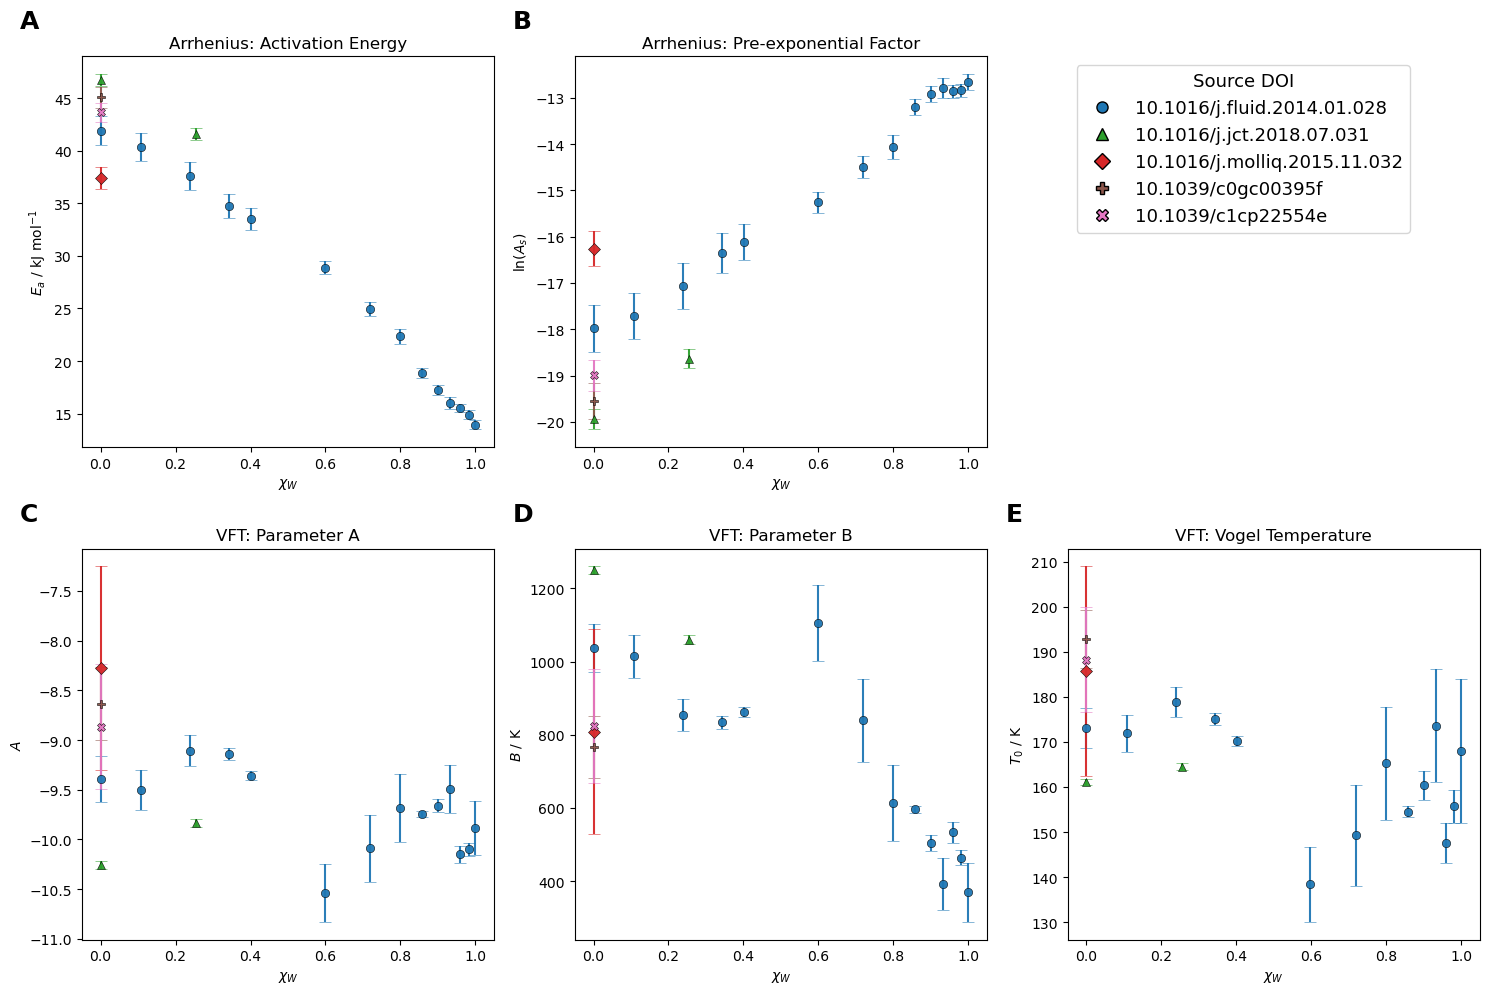

In [12]:
# Arrhenius vs VFT in 2x3 layout

import matplotlib.pyplot as plt
import pandas as pd

# Defensive copies
arr_plot = arr_df2.copy()
vft_plot = vft_df.copy()

# Shared DOI style mapping (same colors/markers across both models)
all_dois = sorted(
    set(arr_plot["source_doi"].dropna().astype(str).unique())
    | set(vft_plot["source_doi"].dropna().astype(str).unique())
)
doi_style = {doi: get_doi_style(doi) for doi in all_dois}

# Ensure needed axes columns exist
arr_plot = arr_plot[arr_plot["source_doi"].notna() & arr_plot["mole_fraction_water"].notna()].copy()
vft_plot = vft_plot[vft_plot["source_doi"].notna() & vft_plot["mole_fraction_water"].notna()].copy()
arr_plot["source_doi"] = arr_plot["source_doi"].astype(str)
vft_plot["source_doi"] = vft_plot["source_doi"].astype(str)

# Create 2x3 figure exactly like BayesianInference layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- Add subplot letter labels (A-E), keep top-right for legend ---
label_dict = {
    (0, 0): "A",
    (0, 1): "B",
    (1, 0): "C",
    (1, 1): "D",
    (1, 2): "E",
}
label_x_offset = -0.15
label_y_offset = 1.12
for (i, j), label in label_dict.items():
    axes[i, j].text(
        label_x_offset,
        label_y_offset,
        label,
        transform=axes[i, j].transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left",
    )

# -------- Row 1: Arrhenius --------
# A) Activation energy
ax = axes[0, 0]
for doi in all_dois:
    subset = arr_plot[arr_plot["source_doi"] == doi]
    if subset.empty:
        continue

    y = subset["Ea_kJ_mol"]
    style = doi_style[doi]

    if "Ea_kJ_mol_std" in subset.columns:
        yerr = pd.to_numeric(subset["Ea_kJ_mol_std"], errors="coerce")
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
            label=doi,
        )
    else:
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            fmt=style["marker"],
            color=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
            label=doi,
        )

ax.set_xlabel('$χ_W$')
ax.set_ylabel('$E_a$ / kJ mol$^{-1}$')
ax.set_title('Arrhenius: Activation Energy')

# B) Pre-exponential factor
ax = axes[0, 1]
for doi in all_dois:
    subset = arr_plot[arr_plot["source_doi"] == doi]
    if subset.empty:
        continue

    style = doi_style[doi]
    y = subset["lnAs"]

    # Use lnAs_std if available, otherwise marker-only
    if "lnAs_std" in subset.columns:
        yerr = pd.to_numeric(subset["lnAs_std"], errors="coerce")
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )
    else:
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            fmt=style["marker"],
            color=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )

ax.set_xlabel('$χ_W$')
ax.set_ylabel('ln($A_s$)')
ax.set_title('Arrhenius: Pre-exponential Factor')

# Top-right reserved for legend exactly like BayesianInference
axes[0, 2].axis('off')

# -------- Row 2: VFT --------
# C) Parameter A (mapped from ln_eta0 in your vft_df)
ax = axes[1, 0]
for doi in all_dois:
    subset = vft_plot[vft_plot["source_doi"] == doi]
    if subset.empty:
        continue

    style = doi_style[doi]
    y = subset["ln_eta0"]

    if "ln_eta0_std" in subset.columns:
        yerr = pd.to_numeric(subset["ln_eta0_std"], errors="coerce")
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )
    else:
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            fmt=style["marker"],
            color=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )

ax.set_xlabel('$χ_W$')
ax.set_ylabel('$A$')
ax.set_title('VFT: Parameter A')

# D) Parameter B
ax = axes[1, 1]
for doi in all_dois:
    subset = vft_plot[vft_plot["source_doi"] == doi]
    if subset.empty:
        continue

    style = doi_style[doi]
    y = subset["B"]

    if "B_std" in subset.columns:
        yerr = pd.to_numeric(subset["B_std"], errors="coerce")
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )
    else:
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            fmt=style["marker"],
            color=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )

ax.set_xlabel('$χ_W$')
ax.set_ylabel('$B$ / K')
ax.set_title('VFT: Parameter B')

# E) Vogel temperature T0
ax = axes[1, 2]
for doi in all_dois:
    subset = vft_plot[vft_plot["source_doi"] == doi]
    if subset.empty:
        continue

    style = doi_style[doi]
    y = subset["T0"]

    if "T0_std" in subset.columns:
        yerr = pd.to_numeric(subset["T0_std"], errors="coerce")
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            yerr=yerr,
            fmt=style["marker"],
            color=style["color"],
            ecolor=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )
    else:
        ax.errorbar(
            subset["mole_fraction_water"],
            y,
            fmt=style["marker"],
            color=style["color"],
            markeredgecolor="black",
            markeredgewidth=0.4,
            markersize=6,
            capsize=4,
            linestyle="none",
            alpha=0.95,
        )

ax.set_xlabel('$χ_W$')
ax.set_ylabel('$T_0$ / K')
ax.set_title('VFT: Vogel Temperature')

# Legend in empty top-right panel
axes[0, 2].legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            marker=doi_style[doi]['marker'],
            color='w',
            markerfacecolor=doi_style[doi]['color'],
            markeredgecolor='k',
            markersize=8,
            label=doi,
        )
        for doi in all_dois
    ],
    title='Source DOI',
    loc='upper left',
    bbox_to_anchor=(0, 1.0),
    fontsize=13,
    title_fontsize=13,
    frameon=True,
)
axes[0, 2].axis('off')

plt.tight_layout()
plt.show()



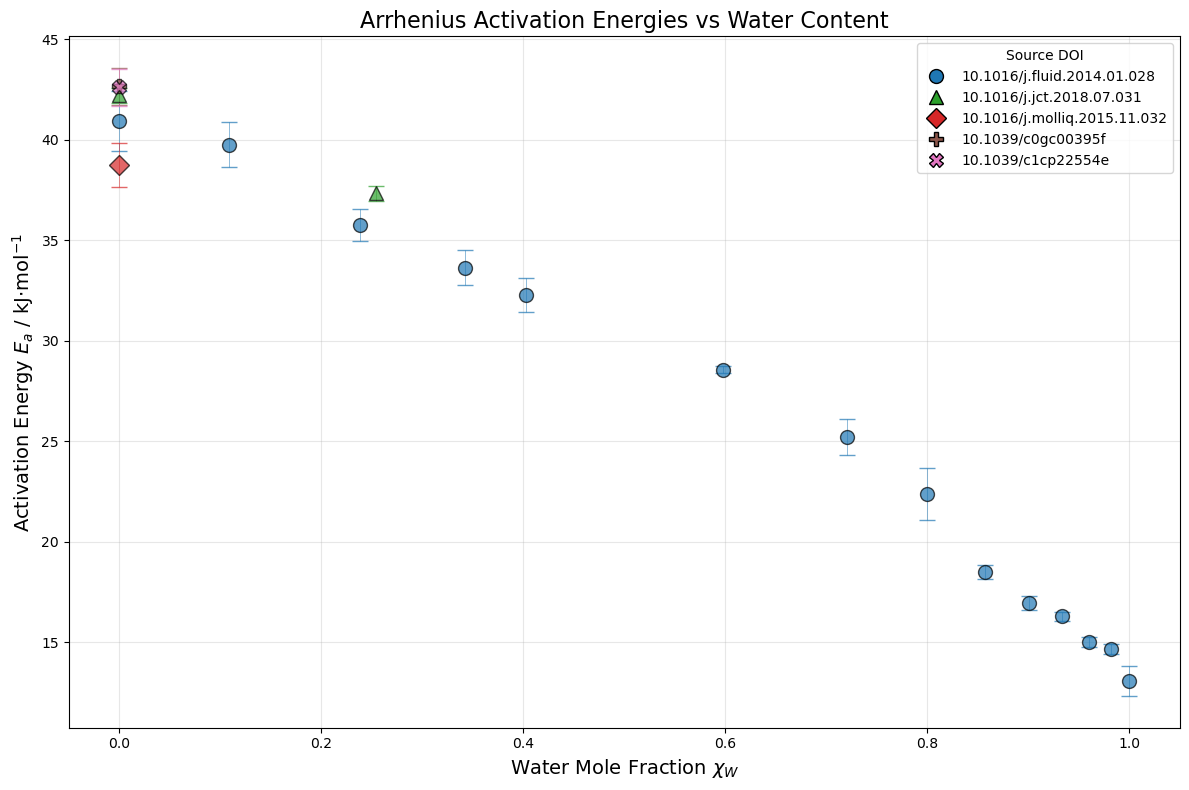

,source_doi,mole_fractions,lnAs,Ea_kJ_mol,Ea_kJ_mol_std,R_squared,n_points
0,10.1016/j.fluid.2014.01.028,"(0.006033, 0.012067, 0.9819)",-12.771025,14.659869,0.248407,0.999139,5
1,10.1016/j.fluid.2014.01.028,"(0.013267, 0.026533, 0.9602)",-12.680843,14.999807,0.252410,0.999151,5
2,10.1016/j.fluid.2014.01.028,"(0.022167, 0.044333, 0.9335)",-12.918128,16.279363,0.213907,0.999482,5
3,10.1016/j.fluid.2014.01.028,"(0.0331, 0.0662, 0.9007)",-12.852232,16.940396,0.329417,0.998867,5
4,10.1016/j.fluid.2014.01.028,"(0.047533, 0.095067, 0.8574)",-13.079436,18.502606,0.350862,0.998922,5
5,10.1016/j.fluid.2014.01.028,"(0.066767, 0.133533, 0.7997)",-14.104252,22.376916,1.281737,0.990253,5
6,10.1016/j.fluid.2014.01.028,"(0.093367, 0.186733, 0.7199)",-14.628448,25.216655,0.899113,0.996201,5
7,10.1016/j.fluid.2014.01.028,"(0.134067, 0.268133, 0.5978)",-15.173126,28.544322,0.168817,0.999895,5
8,10.1016/j.fluid.2014.01.028,"(0.199267, 0.398533, 0.4022)",-15.708462,32.276184,0.862961,0.997860,5
9,10.1016/j.fluid.2014.01.028,"(0.219167, 0.438333, 0.3425)",-16.000052,33.627398,0.867953,0.998005,5


In [13]:

import matplotlib.pyplot as plt

# Use DOI_STYLES and get_doi_style from module context

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Get unique DOIs for coloring and markering using consistent style
unique_dois = arr_df['source_doi'].unique()
doi_styles = {doi: get_doi_style(doi) for doi in unique_dois}

# Use standard deviation if available
std_col = None
for possible in ['Ea_std', 'Ea_kJ_mol_std', 'Ea_std_kJ_mol', 'Ea_kJ_std']:  # handle different possible std column names
    if possible in arr_df.columns:
        std_col = possible
        break

# Plot each row as a point with error bars if std is present
first_idx_by_doi = {doi: arr_df[arr_df['source_doi'] == doi].index[0] for doi in unique_dois}

for idx, row in arr_df.iterrows():
    doi = row['source_doi']
    ea = row['Ea_kJ_mol']
    water_fraction = row['mole_fraction_water']
    style = doi_styles[doi]
    # Only label the first point for each DOI for the legend
    label = doi if idx == first_idx_by_doi[doi] else ""

    yerr = row[std_col] if std_col is not None and not pd.isna(row[std_col]) else None

    ax.errorbar(
        water_fraction,
        ea,
        yerr=yerr,
        fmt=style['marker'],
        color=style['color'],
        markersize=10,
        alpha=0.7,
        markeredgecolor='black',
        markerfacecolor=style['color'],
        linewidth=0.5,
        capsize=6 if yerr is not None else 0,
        label=label if yerr is None or (type(yerr) in (float, int) and yerr == 0) else None # avoid duplicate legends
    )
    # If you want the label to appear even if errorbars exist only for the first, modify as needed.

ax.set_xlabel(r'Water Mole Fraction $\chi_W$', fontsize=14)
ax.set_ylabel(r'Activation Energy $E_a$ / kJ$\cdot$mol$^{-1}$', fontsize=14)
ax.set_title('Arrhenius Activation Energies vs Water Content', fontsize=16)
ax.grid(True, alpha=0.3)

# Create consistent legend (one marker per DOI, consistently styled)
from matplotlib.lines import Line2D
legend_handles = [
    Line2D(
        [0], [0],
        marker=doi_styles[doi]['marker'],
        color='w',
        label=doi,
        markerfacecolor=doi_styles[doi]['color'],
        markeredgecolor='black',
        markersize=10,
        linewidth=0
    ) for doi in unique_dois
]

ax.legend(
    handles=legend_handles,
    loc='best',
    fontsize=10,
    title="Source DOI"
)

plt.tight_layout()
plt.show()

display_cols = ["source_doi", "mole_fractions", "lnAs", "Ea_kJ_mol", "R_squared", "n_points"]
if std_col:
    display_cols.insert(display_cols.index("Ea_kJ_mol")+1, std_col)
display(arr_df[display_cols])

✓ Plot gespeichert: image_output/Arrhenius_Plots_Temperature_Groups_by_DOI_water-fr_2.svg (184,717 Bytes)


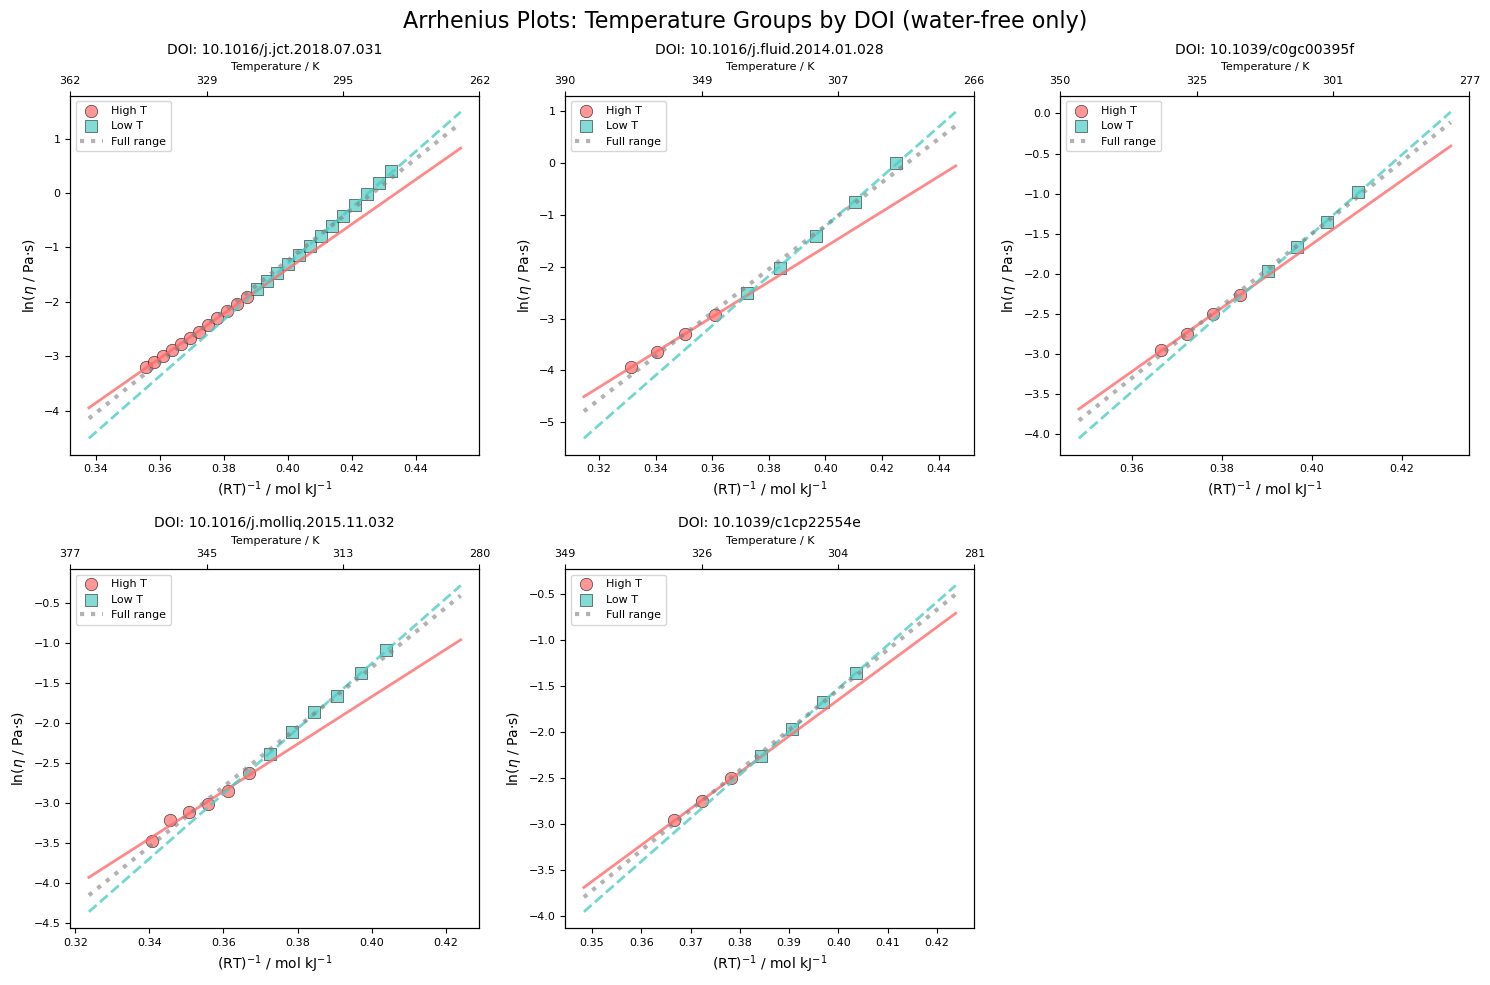

Split points DataFrame shape: (61, 11)

Temperature group distribution:
temperature_group
Low T     32
High T    29
Name: count, dtype: int64


,fluid_compounds,mole_fractions,viscosity_value,viscosity_uncertainty,temperature,source_doi,Solvent: Amount ratio of component to other component of binary solvent,mole_fraction_water,inv_RT,ln_viscosity,temperature_group
0,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.04094,0.000819,338.15,10.1016/j.jct.2018.07.031,2.0,0.0,0.355697,-3.195648,High T
1,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.04519,0.000904,335.65,10.1016/j.jct.2018.07.031,2.0,0.0,0.358347,-3.096879,High T
2,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.05005,0.001001,333.15,10.1016/j.jct.2018.07.031,2.0,0.0,0.361036,-2.994733,High T
3,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.05563,0.001113,330.65,10.1016/j.jct.2018.07.031,2.0,0.0,0.363765,-2.889033,High T
4,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.06206,0.001241,328.15,10.1016/j.jct.2018.07.031,2.0,0.0,0.366537,-2.779654,High T
5,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.06946,0.001389,325.65,10.1016/j.jct.2018.07.031,2.0,0.0,0.369351,-2.667004,High T
6,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.07839,0.001568,323.15,10.1016/j.jct.2018.07.031,2.0,0.0,0.372208,-2.546059,High T
7,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.08843,0.001769,320.65,10.1016/j.jct.2018.07.031,2.0,0.0,0.375110,-2.425544,High T
8,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.10000,0.002,318.15,10.1016/j.jct.2018.07.031,2.0,0.0,0.378058,-2.302585,High T
9,"[Choline Chloride, Glycerol]","[0.333333333333, 0.666666666667]",0.11380,0.002276,315.65,10.1016/j.jct.2018.07.031,2.0,0.0,0.381052,-2.173313,High T



Arrhenius fit parameters (Ea = slope, lneta0 = intercept):


,source_doi,temperature_group,Ea,lneta0,n_points
0,10.1016/j.jct.2018.07.031,High T,41.070883,-17.823342,12
1,10.1016/j.jct.2018.07.031,Low T,51.628376,-21.951472,13
2,10.1016/j.jct.2018.07.031,Full Range,46.748109,-19.938777,25
3,10.1016/j.fluid.2014.01.028,High T,33.879814,-15.165900,4
4,10.1016/j.fluid.2014.01.028,Low T,47.916282,-20.385919,5
5,10.1016/j.fluid.2014.01.028,Full Range,41.925535,-17.979190,9
6,10.1039/c0gc00395f,High T,39.776179,-17.542429,4
7,10.1039/c0gc00395f,Low T,49.362422,-21.246557,4
8,10.1039/c0gc00395f,Full Range,45.099537,-19.540212,8
9,10.1016/j.molliq.2015.11.032,High T,29.642978,-13.525274,6


In [14]:
# Plot arr_df grouped by DOI, splitting temperature points into low and high temperature groups
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep only water-free records (water fraction == 0)
water_col = "water_fraction" if "water_fraction" in plot_df.columns else "mole_fraction_water"
plot_df_no_water = plot_df[np.isclose(plot_df[water_col].fillna(0.0).astype(float), 0.0)].copy()

# Get unique DOIs from water-free data only
unique_dois = plot_df_no_water['source_doi'].unique()

# Filter out DOIs with insufficient data first
valid_dois = []
for doi in unique_dois:
    subset = plot_df_no_water[
        (plot_df_no_water["source_doi"] == doi)
        & (~plot_df_no_water["inv_RT"].isna())
        & (~plot_df_no_water["ln_viscosity"].isna())
    ]
    if len(subset) >= 2:
        valid_dois.append(doi)

# Calculate number of subplots needed
n_dois = len(valid_dois)
n_cols = 3  # Number of columns
n_rows = (n_dois + n_cols - 1) // n_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten axes array for easier indexing
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Color map for temperature groups
temp_colors = {'High T': '#FF6B6B', 'Low T': '#4ECDC4'}

# List to store all split data and the fit parameters
split_data = []
fit_params = []  # Will store Ea (slope) and lneta0 (intercept)

# Universal gas constant (for reporting in output table)
R = 8.314462618  # J/mol/K

# Process each valid DOI
for i, doi in enumerate(valid_dois):
    ax = axes[i]
    
    subset = plot_df_no_water[
        (plot_df_no_water["source_doi"] == doi)
        & (~plot_df_no_water["inv_RT"].isna())
        & (~plot_df_no_water["ln_viscosity"].isna())
    ]
    
    # Sort by temperature (inverse of inv_RT for proper ordering)
    subset_sorted = subset.sort_values('inv_RT')
    
    # Split into two halves based on temperature
    n_points = len(subset_sorted)
    mid_point = n_points // 2
    
    # Lower half (higher temperatures - lower inv_RT values)
    low_temp_group = subset_sorted.iloc[:mid_point].copy()
    low_temp_group['temperature_group'] = 'High T'
    
    # Upper half (lower temperatures - higher inv_RT values)  
    high_temp_group = subset_sorted.iloc[mid_point:].copy()
    high_temp_group['temperature_group'] = 'Low T'
    
    # Add to split_data list
    split_data.append(low_temp_group)
    split_data.append(high_temp_group)
    
    # Get x-axis range for extending lines in 1/(R*T) units
    x_range_min = subset_sorted["inv_RT"].min() * 0.95
    x_range_max = subset_sorted["inv_RT"].max() * 1.05
    
    # Plot high temperature group (circles)
    if len(low_temp_group) > 0:
        ax.scatter(
            low_temp_group["inv_RT"],
            low_temp_group["ln_viscosity"],
            label='High T',
            color=temp_colors['High T'],
            marker='o',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for high temperature group
        if len(low_temp_group) >= 2:
            x_high = low_temp_group["inv_RT"].values
            y_high = low_temp_group["ln_viscosity"].values
            slope_high, intercept_high = np.polyfit(x_high, y_high, 1)
            
            fit_params.append({
                'source_doi': doi,
                'temperature_group': 'High T',
                'Ea': slope_high,           # Slope is Ea (activation energy)
                'lneta0': intercept_high,   # Intercept is ln A (lneta0)
                'n_points': len(low_temp_group)
            })
            
            # Create extended line points for plotting
            x_line_high = np.linspace(x_range_min, x_range_max, 100)
            y_line_high = slope_high * x_line_high + intercept_high
            
            ax.plot(x_line_high, y_line_high, color=temp_colors['High T'], 
                   linestyle='-', alpha=0.8, linewidth=2)
    
    # Plot low temperature group (squares)
    if len(high_temp_group) > 0:
        ax.scatter(
            high_temp_group["inv_RT"],
            high_temp_group["ln_viscosity"],
            label='Low T',
            color=temp_colors['Low T'],
            marker='s',
            s=80,
            alpha=0.7,
            edgecolor='black',
            linewidth=0.5
        )
        
        # Fit and plot extended Arrhenius line for low temperature group
        if len(high_temp_group) >= 2:
            x_low = high_temp_group["inv_RT"].values
            y_low = high_temp_group["ln_viscosity"].values
            slope_low, intercept_low = np.polyfit(x_low, y_low, 1)

            fit_params.append({
                'source_doi': doi,
                'temperature_group': 'Low T',
                'Ea': slope_low,
                'lneta0': intercept_low,
                'n_points': len(high_temp_group)
            })
            
            # Create extended line points for plotting
            x_line_low = np.linspace(x_range_min, x_range_max, 100)
            y_line_low = slope_low * x_line_low + intercept_low
            
            ax.plot(x_line_low, y_line_low, color=temp_colors['Low T'], 
                   linestyle='--', alpha=0.8, linewidth=2)
    
    # Plot extended full range Arrhenius line
    if len(subset_sorted) >= 2:
        x_full = subset_sorted["inv_RT"].values
        y_full = subset_sorted["ln_viscosity"].values
        slope_full, intercept_full = np.polyfit(x_full, y_full, 1)

        fit_params.append({
            'source_doi': doi,
            'temperature_group': 'Full Range',
            'Ea': slope_full,
            'lneta0': intercept_full,
            'n_points': len(subset_sorted)
        })
        
        # Create extended line points for plotting
        x_line_full = np.linspace(x_range_min, x_range_max, 100)
        y_line_full = slope_full * x_line_full + intercept_full
        
        ax.plot(x_line_full, y_line_full, color='gray', 
               linestyle=':', alpha=0.6, linewidth=3, label='Full range')
    
    # Set labels and title for each subplot
    ax.set_xlabel(r'(RT)$^{-1}$ / mol kJ$^{-1}$', fontsize=10)
    ax.set_ylabel(r'ln($\eta$ / Pa$\cdot$s)', fontsize=10)
    ax.set_title(f'DOI: {doi}', fontsize=10, wrap=True)
    
    # Add legend to each subplot
    ax.legend(fontsize=8, loc='best')
    
    # Increase tick label font size
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Create secondary x-axis for temperature
    ax_temp = ax.twiny()
    
    # Get the current x-axis limits in 1/(R*T) units
    x_min, x_max = ax.get_xlim()
    
    # Convert 1/(R*T) to temperature (K): inv_RT = 1000 / (R*T)
    T_min = 1000 / (R * x_max)  # Higher 1/(R*T) corresponds to lower temperature
    T_max = 1000 / (R * x_min)  # Lower 1/(R*T) corresponds to higher temperature
    
    # Set temperature axis limits and ticks
    ax_temp.set_xlim(T_max, T_min)
    temp_ticks = np.linspace(T_max, T_min, 4)  # Fewer ticks for smaller plots
    ax_temp.set_xticks(temp_ticks)
    ax_temp.set_xticklabels([f'{T:.0f}' for T in temp_ticks], fontsize=8)
    ax_temp.set_xlabel('Temperature / K', fontsize=8)
    ax_temp.tick_params(axis='x', which='major', labelsize=8)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Add overall title
fig.suptitle('Arrhenius Plots: Temperature Groups by DOI (water-free only)', 
             fontsize=16, y=0.98)

plt.tight_layout()
save_plot_as_svg()
plt.show()

# Combine all split data into a single DataFrame
split_points_df = pd.concat(split_data, ignore_index=True)
fit_params_df = pd.DataFrame(fit_params)

print(f"Split points DataFrame shape: {split_points_df.shape}")
print("\nTemperature group distribution:")
print(split_points_df['temperature_group'].value_counts())
display(split_points_df.head(10))

print("\nArrhenius fit parameters (Ea = slope, lneta0 = intercept):")
display(fit_params_df)

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use the color column directly
colors = activation_energy_df['color']

# Convert activation energy from J/mol to kJ/mol
activation_energy_kJ = activation_energy_df['activation_energy'] / 1000

scatter = plt.scatter(
    activation_energy_df['ordinate'],
    activation_energy_kJ,
    c=colors,
    s=60
)

# Make a discrete legend per source_doi using the color column
unique_dois = activation_energy_df['source_doi'].unique()
from matplotlib.patches import Patch
legend_handles = []
for doi in unique_dois:
    # Get the color for this DOI from the first occurrence
    color = activation_energy_df[activation_energy_df['source_doi'] == doi]['color'].iloc[0]
    legend_handles.append(Patch(facecolor=color, label=f"{doi}"))

plt.legend(handles=legend_handles, title="Source DOI", bbox_to_anchor=(1.04, 1), loc='upper left')

plt.xlabel('ln(As / Pa·s)')
plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')

plt.tight_layout()
save_plot_as_svg()
plt.show()


<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_42689/3236673562.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')
/tmp/ipykernel_42689/3236673562.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Activation Energy $E_a$ / $kJ \cdot mol^{-1}$')


KeyError: 'color'

<Figure size 1000x600 with 0 Axes>